In [2]:
MEMBER_NAME = "Chandrasekara B.P.G.I.L"
IT_NUMBER = "IT25102140"
TASK = "Dataset Audit + Cleaning"

print(MEMBER_NAME)
print(IT_NUMBER)
print(TASK)

Chandrasekara B.P.G.I.L
IT25102140
Dataset Audit + Cleaning


In [4]:
from google.colab import drive

drive.mount("/content/drive")

print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


In [5]:
!pip -q install pandas pillow matplotlib numpy imagehash

import os
import shutil
import hashlib
import json
import csv
import math

from pathlib import Path

import pandas as pd
import numpy as np

from PIL import Image, ImageFile

import matplotlib.pyplot as plt

ImageFile.LOAD_TRUNCATED_IMAGES = False

print("Packages imported successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 3.7 MB/s eta 0:00:00
Packages imported successfully.


In [6]:
from pathlib import Path

PROJECT = Path("/content/drive/MyDrive/Waste_Classification")

RAW_DIR = PROJECT / "data" / "raw"
PROCESSED_DIR = PROJECT / "data" / "processed"

RESULTS_DIR = PROJECT / "results"
REPORT_DIR = PROJECT / "audit_reports"

EDA_DIR = RESULTS_DIR / "eda_visualizations"
OUTPUT_DIR = RESULTS_DIR / "outputs"

for folder in [
    RAW_DIR,
    PROCESSED_DIR,
    RESULTS_DIR,
    REPORT_DIR,
    EDA_DIR,
    OUTPUT_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders created successfully.")
print("PROJECT:", PROJECT)
print("RAW DATASET MUST GO HERE:", RAW_DIR)

Project folders created successfully.
PROJECT: /content/drive/MyDrive/Waste_Classification
RAW DATASET MUST GO HERE: /content/drive/MyDrive/Waste_Classification/data/raw


In [7]:
!pip -q install -U kagglehub

import kagglehub

dataset_path = kagglehub.dataset_download(
    "phenomsg/waste-classification",
    output_dir=str(RAW_DIR)
)

print("Dataset downloaded successfully.")
print("Dataset location:", dataset_path)

100%|██████████| 1.02G/1.02G [00:13<00:00, 82.7MB/s]

Extracting files...


Dataset downloaded successfully.
Dataset location: /content/drive/MyDrive/Waste_Classification/data/raw


In [8]:
IMAGE_EXTS = {
    ".jpg", ".jpeg", ".png", ".webp",
    ".bmp", ".gif", ".tif", ".tiff"
}

print("TOP-LEVEL ITEMS INSIDE RAW DATASET:\n")

for item in sorted(RAW_DIR.iterdir()):
    if item.is_dir():
        print("📁 Folder:", item.name)
    else:
        print("📄 File:", item.name)

print("\n------------------------------")

raw_files = sorted([
    p for p in RAW_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS
])

print("TOTAL IMAGE COUNT:", len(raw_files))

TOP-LEVEL ITEMS INSIDE RAW DATASET:

📁 Folder: .complete
📁 Folder: Hazardous
📁 Folder: Non-Recyclable
📁 Folder: Organic
📁 Folder: Recyclable

------------------------------
TOTAL IMAGE COUNT: 2935


In [9]:
from collections import Counter

folder_counts = Counter()

for p in raw_files:
    relative_path = p.relative_to(RAW_DIR)

    if len(relative_path.parts) > 0:
        main_folder = relative_path.parts[0]
        folder_counts[main_folder] += 1

print("IMAGE COUNT BY TOP-LEVEL FOLDER:\n")

for folder, count in sorted(folder_counts.items()):
    print(folder, ":", count)

IMAGE COUNT BY TOP-LEVEL FOLDER:

Hazardous : 949
Non-Recyclable : 647
Organic : 677
Recyclable : 662


In [10]:
records = []

for p in raw_files:

    rel = p.relative_to(RAW_DIR)

    # Main folder = class
    cls = rel.parts[0] if rel.parts else "UNKNOWN"

    row = {
        "relative_path": str(rel),
        "filename": p.name,
        "class": cls,
        "extension": p.suffix.lower(),
        "file_size_bytes": p.stat().st_size,
        "status": "KEEP",
        "reason": "",
        "width": None,
        "height": None,
        "mode": None
    }

    try:
        # Check whether the image file is valid
        with Image.open(p) as im:
            im.verify()

        # Re-open it to obtain image information
        with Image.open(p) as im:
            row["width"] = im.size[0]
            row["height"] = im.size[1]
            row["mode"] = im.mode

    except Exception as e:
        row["status"] = "EXCLUDE_CORRUPT"
        row["reason"] = repr(e)[:500]

    records.append(row)

audit_df = pd.DataFrame(records)

print("AUDIT COMPLETE")
print()
print(audit_df["status"].value_counts())

display(audit_df.head())

/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


AUDIT COMPLETE

status
KEEP    2935
Name: count, dtype: int64


,relative_path,filename,class,extension,file_size_bytes,status,reason,width,height,mode
0,Hazardous/Hazardous/batteries/1-s2.0-S08926875...,1-s2.0-S0892687521004477-ga1.jpg,Hazardous,.jpg,29714,KEEP,,447,200,RGB
1,Hazardous/Hazardous/batteries/1-s2.0-S24058297...,1-s2.0-S2405829720304827-fx1.jpg,Hazardous,.jpg,38350,KEEP,,245,245,RGB
2,Hazardous/Hazardous/batteries/1-s2.0-S26660164...,1-s2.0-S2666016421000268-ga1.jpg,Hazardous,.jpg,32747,KEEP,,340,200,RGB
3,Hazardous/Hazardous/batteries/12209_2020_236_F...,12209_2020_236_Fig1_HTML.png,Hazardous,.png,417103,KEEP,,685,641,RGB
4,Hazardous/Hazardous/batteries/12209_2020_236_F...,12209_2020_236_Fig2_HTML.png,Hazardous,.png,243214,KEEP,,685,436,RGB


In [11]:
import warnings

warning_records = []
load_errors = []

for p in raw_files:

    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")

        try:
            with Image.open(p) as im:
                im.load()   # Fully load the image pixels

        except Exception as e:
            load_errors.append({
                "file": str(p.relative_to(RAW_DIR)),
                "error": repr(e)
            })

        for w in caught:
            warning_records.append({
                "file": str(p.relative_to(RAW_DIR)),
                "warning": str(w.message)
            })

print("FULL IMAGE LOAD ERRORS:", len(load_errors))
print("WARNINGS FOUND:", len(warning_records))

if load_errors:
    print("\nLOAD ERRORS:")
    display(pd.DataFrame(load_errors))

if warning_records:
    print("\nWARNINGS:")
    display(pd.DataFrame(warning_records))

FULL IMAGE LOAD ERRORS: 0
WARNINGS FOUND: 1

WARNINGS:


,file,warning
0,Non-Recyclable/Non-Recyclable/diapers/baby-dia...,Truncated File Read


In [12]:
audit_path = REPORT_DIR / "member1_image_audit.csv"

audit_df.to_csv(audit_path, index=False)

print("Full image audit saved successfully.")
print("Saved to:", audit_path)

Full image audit saved successfully.
Saved to: /content/drive/MyDrive/Waste_Classification/audit_reports/member1_image_audit.csv


In [13]:
warning_df = pd.DataFrame(warning_records)

warning_path = REPORT_DIR / "member1_image_warnings.csv"

warning_df.to_csv(warning_path, index=False)

print("Warning report saved successfully.")
print("Warnings recorded:", len(warning_df))
print("Saved to:", warning_path)

Warning report saved successfully.
Warnings recorded: 1
Saved to: /content/drive/MyDrive/Waste_Classification/audit_reports/member1_image_warnings.csv


CLASS DISTRIBUTION:
class
Hazardous         949
Non-Recyclable    647
Organic           677
Recyclable        662
Name: count, dtype: int64


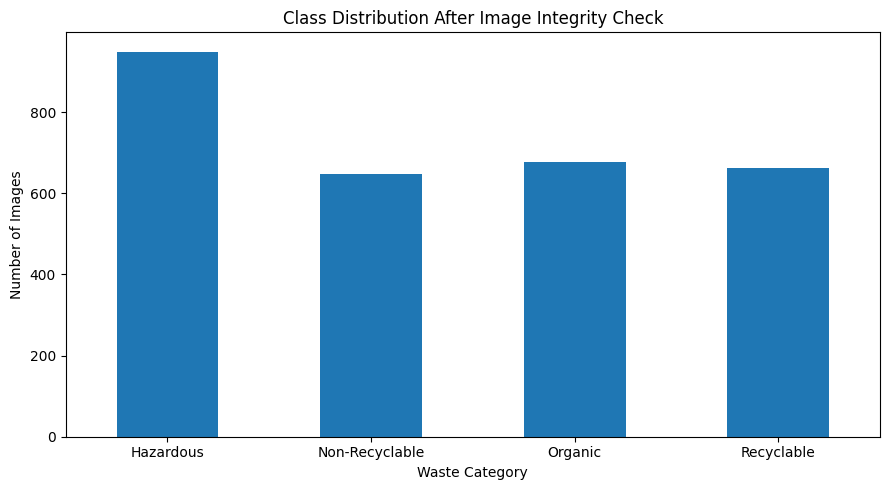

Graph saved to: /content/drive/MyDrive/Waste_Classification/results/eda_visualizations/member1_class_distribution.png


In [14]:
valid = audit_df[audit_df["status"] == "KEEP"]

class_counts = valid["class"].value_counts().sort_index()

print("CLASS DISTRIBUTION:")
print(class_counts)

plt.figure(figsize=(9, 5))

class_counts.plot(kind="bar")

plt.title("Class Distribution After Image Integrity Check")
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")

plt.xticks(rotation=0)

plt.tight_layout()

eda_path = EDA_DIR / "member1_class_distribution.png"

plt.savefig(eda_path, dpi=200)

plt.show()

print("Graph saved to:", eda_path)

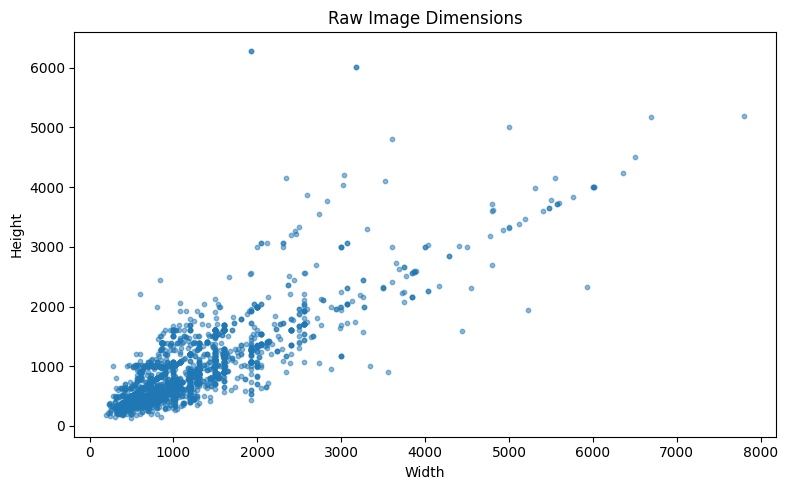

Dimension graph saved to: /content/drive/MyDrive/Waste_Classification/results/eda_visualizations/member1_dimensions.png


In [15]:
plt.figure(figsize=(8, 5))

plt.scatter(
    valid["width"],
    valid["height"],
    s=10,
    alpha=0.5
)

plt.title("Raw Image Dimensions")
plt.xlabel("Width")
plt.ylabel("Height")

plt.tight_layout()

dimension_path = EDA_DIR / "member1_dimensions.png"

plt.savefig(dimension_path, dpi=200)

plt.show()

print("Dimension graph saved to:", dimension_path)

In [16]:
print("IMAGE DIMENSION SUMMARY")

print("\nWidth:")
print(valid["width"].describe())

print("\nHeight:")
print(valid["height"].describe())

print("\nDifferent image sizes:",
      valid[["width", "height"]].drop_duplicates().shape[0])

IMAGE DIMENSION SUMMARY

Width:
count    2935.000000
mean     1199.240886
std       770.398477
min       200.000000
25%       728.000000
50%      1024.000000
75%      1475.500000
max      7800.000000
Name: width, dtype: float64

Height:
count    2935.000000
mean      912.636797
std       629.448962
min       128.000000
25%       500.000000
50%       734.000000
75%      1101.000000
max      6286.000000
Name: height, dtype: float64

Different image sizes: 1553


In [17]:
STAGE1 = PROCESSED_DIR / "stage1_cleaning"

STAGE1.mkdir(parents=True, exist_ok=True)

for _, row in valid.iterrows():

    src = RAW_DIR / row["relative_path"]
    dst = STAGE1 / row["relative_path"]

    dst.parent.mkdir(parents=True, exist_ok=True)

    shutil.copy2(src, dst)

print("Stage 1 cleaned dataset created.")
print("Saved to:", STAGE1)

Stage 1 cleaned dataset created.
Saved to: /content/drive/MyDrive/Waste_Classification/data/processed/stage1_cleaning


In [18]:
stage1_files = [
    p for p in STAGE1.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS
]

print("Valid images from audit:", len(valid))
print("Images inside Stage 1:", len(stage1_files))

assert len(stage1_files) == len(valid)

print("Stage 1 verification PASSED.")

Valid images from audit: 2935
Images inside Stage 1: 2935
Stage 1 verification PASSED.


In [19]:
stage1_manifest = OUTPUT_DIR / "member1_stage1_manifest.csv"

valid.to_csv(stage1_manifest, index=False)

print("Stage 1 manifest saved successfully.")
print("Rows in manifest:", len(valid))
print("Saved to:", stage1_manifest)

Stage 1 manifest saved successfully.
Rows in manifest: 2935
Saved to: /content/drive/MyDrive/Waste_Classification/results/outputs/member1_stage1_manifest.csv


In [20]:
for folder in [
    PROJECT / "notebooks",
    PROJECT / "code",
    PROJECT / "results",
    PROJECT / "results" / "eda_visualizations",
    PROJECT / "audit_reports"
]:
    folder.mkdir(parents=True, exist_ok=True)

readme = PROJECT / "README.md"

if not readme.exists():
    readme.write_text(
        """# Waste Classification AIML Project

Six-member preprocessing pipeline:

01 Cleaning
02 Duplicate detection
03 Label validation
04 Image standardization
05 Normalization
06 Training-only augmentation

Final integration occurs in group_pipeline.ipynb.
"""
    )

print("Common project structure prepared.")
print("README:", readme)

Common project structure prepared.
README: /content/drive/MyDrive/Waste_Classification/README.md


In [22]:
print("=== CHANDRASEKARA FILE CHECK ===")

important_files = [
    PROJECT / "notebooks" / "IT25102140_DatasetCleaning.ipynb",
    REPORT_DIR / "member1_image_audit.csv",
    REPORT_DIR / "member1_image_warnings.csv",
    OUTPUT_DIR / "member1_stage1_manifest.csv",
    EDA_DIR / "member1_class_distribution.png",
    EDA_DIR / "member1_dimensions.png",
    PROJECT / "README.md"
]

for file in important_files:
    print(("✅" if file.exists() else "❌"), file.name)

=== CHANDRASEKARA FILE CHECK ===
✅ IT25102140_DatasetCleaning.ipynb
✅ member1_image_audit.csv
✅ member1_image_warnings.csv
✅ member1_stage1_manifest.csv
✅ member1_class_distribution.png
✅ member1_dimensions.png
✅ README.md


In [23]:
gitignore = PROJECT / ".gitignore"

gitignore.write_text("""
# Large datasets
data/raw/
data/processed/

# Trained model files
*.h5
*.keras
*.pt
*.pth
*.ckpt

# Python temporary files
__pycache__/
*.pyc

# System files
.DS_Store

# Colab/Jupyter checkpoints
.ipynb_checkpoints/
""".strip())

print(".gitignore created successfully.")
print(gitignore.read_text())

.gitignore created successfully.
# Large datasets
data/raw/
data/processed/

# Trained model files
*.h5
*.keras
*.pt
*.pth
*.ckpt

# Python temporary files
__pycache__/
*.pyc

# System files
.DS_Store

# Colab/Jupyter checkpoints
.ipynb_checkpoints/


In [24]:
!git -C /content/drive/MyDrive/Waste_Classification init
!git -C /content/drive/MyDrive/Waste_Classification branch -M main

print("Git repository initialized.")

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/drive/MyDrive/Waste_Classification/.git/
Git repository initialized.


In [25]:
!git -C /content/drive/MyDrive/Waste_Classification config user.name "IT25102140"
!git -C /content/drive/MyDrive/Waste_Classification config user.email "it25102140@my.sliit.lk"

print("Git identity configured.")

Git identity configured.


In [26]:
!git -C /content/drive/MyDrive/Waste_Classification remote remove origin 2>/dev/null || true

!git -C /content/drive/MyDrive/Waste_Classification remote add origin https://github.com/IT25102140/waste-classification-aiml.git

!git -C /content/drive/MyDrive/Waste_Classification remote -v

origin	https://github.com/IT25102140/waste-classification-aiml.git (fetch)
origin	https://github.com/IT25102140/waste-classification-aiml.git (push)


In [27]:
!git -C /content/drive/MyDrive/Waste_Classification status

On branch main

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.gitignore
	README.md
	audit_reports/
	notebooks/
	results/

nothing added to commit but untracked files present (use "git add" to track)


In [28]:
!git -C /content/drive/MyDrive/Waste_Classification add README.md .gitignore

!git -C /content/drive/MyDrive/Waste_Classification add notebooks/

!git -C /content/drive/MyDrive/Waste_Classification add audit_reports/

!git -C /content/drive/MyDrive/Waste_Classification add results/eda_visualizations/

!git -C /content/drive/MyDrive/Waste_Classification add results/outputs/member1_stage1_manifest.csv

!git -C /content/drive/MyDrive/Waste_Classification status

On branch main

No commits yet

Changes to be committed:
  (use "git rm --cached <file>..." to unstage)
	new file:   .gitignore
	new file:   README.md
	new file:   audit_reports/member1_image_audit.csv
	new file:   audit_reports/member1_image_warnings.csv
	new file:   notebooks/IT25102140_DatasetCleaning.ipynb
	new file:   results/eda_visualizations/member1_class_distribution.png
	new file:   results/eda_visualizations/member1_dimensions.png
	new file:   results/outputs/member1_stage1_manifest.csv



In [29]:
!git -C /content/drive/MyDrive/Waste_Classification commit -m "IT25102140 - dataset audit and cleaning"

[main (root-commit) b91e4bb] IT25102140 - dataset audit and cleaning
 8 files changed, 5907 insertions(+)
 create mode 100644 .gitignore
 create mode 100644 README.md
 create mode 100644 audit_reports/member1_image_audit.csv
 create mode 100644 audit_reports/member1_image_warnings.csv
 create mode 100644 notebooks/IT25102140_DatasetCleaning.ipynb
 create mode 100644 results/eda_visualizations/member1_class_distribution.png
 create mode 100644 results/eda_visualizations/member1_dimensions.png
 create mode 100644 results/outputs/member1_stage1_manifest.csv


In [30]:
!git -C /content/drive/MyDrive/Waste_Classification status

On branch main
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/IT25102140_DatasetCleaning.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
